# RouteZone — Exploration et préparation des données BAAC
#### Meriem Abdelouahed | Formation Dev IA — Simplon x Microsoft

---

## Sommaire

1. [Contexte et consigne](#1-contexte)
2. [Chargement des données](#2-chargement)
3. [Exploration](#3-exploration)
4. [Nettoyage](#4-nettoyage)
5. [Merge — fusion en un seul dataset](#5-merge)
6. [Visualisations](#6-visualisations)
7. [Sauvegarde](#7-sauvegarde)
8. [Conclusion](#8-conclusion)

---

<a id='1-contexte'></a>
## 1. Contexte et consigne

Chaque année en France, environ **50 000 accidents corporels** sont recensés sur les routes.  
L'**ONISR** publie ces données en open data sous le nom **BAAC** (Bulletins d'Analyse des Accidents Corporels).

**Mon objectif :** construire un modèle capable de prédire la **gravité d'un accident**  
à partir des circonstances : heure, météo, type de route, luminosité...

Les données BAAC sont découpées en **4 fichiers par année** :

| Fichier | Contenu | Clé |
|---------|---------|-----|
| `caracteristiques` | Date, heure, météo, GPS... | `Num_Acc` |
| `lieux` | Type de route, profil, vitesse max... | `Num_Acc` |
| `usagers` | Personnes impliquées — **contient la gravité** | `Num_Acc` |
| `vehicules` | Véhicules impliqués | `Num_Acc` |

Je travaille sur **3 années : 2022, 2023, 2024**.

---

<a id='2-chargement'></a>
## 2. Chargement des données

### 2.1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

### 2.2 Définition des chemins

In [2]:
DOSSIER = '../data/raw/'

FICHIERS = {
    'caract'   : {2022: DOSSIER+'caract2022.csv',   2023: DOSSIER+'caract2023.csv',   2024: DOSSIER+'caract2024.csv'},
    'lieux'    : {2022: DOSSIER+'lieux2022.csv',    2023: DOSSIER+'lieux2023.csv',    2024: DOSSIER+'lieux2024.csv'},
    'usagers'  : {2022: DOSSIER+'usagers2022.csv',  2023: DOSSIER+'usagers2023.csv',  2024: DOSSIER+'usagers2024.csv'},
    'vehicules': {2022: DOSSIER+'vehicules2022.csv',2023: DOSSIER+'vehicules2023.csv',2024: DOSSIER+'vehicules2024.csv'},
}

### 2.3 Chargement brut — un fichier à la fois

In [3]:
# je charge les 12 fichiers dans raw[table][annee]
raw = {}

for table in ['caract', 'lieux', 'usagers', 'vehicules']:
    raw[table] = {}
    for annee in [2022, 2023, 2024]:
        df = pd.read_csv(FICHIERS[table][annee], sep=';', encoding='utf-8', low_memory=False)
        raw[table][annee] = df
        print(f'{table}{annee} : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
    print()

caract2022 : 55,302 lignes, 15 colonnes
caract2023 : 54,822 lignes, 15 colonnes
caract2024 : 54,402 lignes, 15 colonnes

lieux2022 : 55,302 lignes, 18 colonnes
lieux2023 : 70,860 lignes, 18 colonnes
lieux2024 : 70,248 lignes, 18 colonnes

usagers2022 : 126,662 lignes, 16 colonnes
usagers2023 : 125,789 lignes, 16 colonnes
usagers2024 : 125,187 lignes, 16 colonnes

vehicules2022 : 94,493 lignes, 11 colonnes
vehicules2023 : 93,585 lignes, 11 colonnes
vehicules2024 : 92,678 lignes, 11 colonnes



<a id='3-exploration'></a>
## 3. Exploration

---

### 3.1 Comparaison des colonnes entre les années

Avant tout, je vérifie que les 3 fichiers d'une même table ont bien les mêmes colonnes.

In [4]:
# je compare les colonnes de chaque table entre 2022, 2023 et 2024
# la référence c'est 2023
for table in ['caract', 'lieux', 'usagers', 'vehicules']:
    print(f'\n--- {table.upper()} ---')
    ref = set(raw[table][2023].columns)
    for annee in [2022, 2023, 2024]:
        cols = set(raw[table][annee].columns)
        en_plus  = cols - ref
        en_moins = ref - cols
        if annee == 2023:
            print(f'  {annee} (ref) : {len(cols)} colonnes')
        elif not en_plus and not en_moins:
            print(f'  {annee}  : identiques')
        else:
            print(f'  {annee} ')
            if en_plus:  print(f'    en plus  : {sorted(en_plus)}')
            if en_moins: print(f'    absentes : {sorted(en_moins)}')


--- CARACT ---
  2022 
    en plus  : ['Accident_Id']
    absentes : ['Num_Acc']
  2023 (ref) : 15 colonnes
  2024  : identiques

--- LIEUX ---
  2022  : identiques
  2023 (ref) : 18 colonnes
  2024  : identiques

--- USAGERS ---
  2022  : identiques
  2023 (ref) : 16 colonnes
  2024  : identiques

--- VEHICULES ---
  2022  : identiques
  2023 (ref) : 11 colonnes
  2024  : identiques


> **Observations :** `caract` 2022 a une colonne `Accident_Id` en plus et `Num_Acc` absente.  
> C'est le même identifiant mais renommé. Si je concatène sans corriger ça va créer deux colonnes séparées  
> et toutes les jointures sur `Num_Acc` pour 2022 vont rater silencieusement.  
> Les autres tables sont cohérentes entre les années 

### 3.2 Aperçu des données — head par table et par année

In [5]:
# un aperçu de chaque fichier pour voir à quoi ressemblent les données
for table in ['caract', 'lieux', 'usagers', 'vehicules']:
    for annee in [2022, 2023, 2024]:
        print(f'\n=== {table} {annee} ===')
        display(raw[table][annee].head(2))


=== caract 2022 ===


,Accident_Id,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"
1,202200000002,20,10,2022,08:34,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000"



=== caract 2023 ===


,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202300000001,7,5,2023,06:00,1,75,75101,2,4,2,7,RUE DE RIVOLI,"48,86638600","2,32347100"
1,202300000002,7,5,2023,05:30,5,94,94080,2,1,3,6,Avenue de Paris,"48,84547782","2,42868146"



=== caract 2024 ===


...

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202200000001,813 952,A01,1,2,0,2,1,9,1,NaN
1,202200000001,813 953,B01,1,7,0,2,2,1,1,NaN



=== vehicules 2023 ===


,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202300000001,155 680 557,A01,1,30,0,0,5,1,1,NaN
1,202300000002,155 680 556,A01,2,7,0,1,1,1,1,NaN



=== vehicules 2024 ===


,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202400000001,155 781 758,A01,1,7,0,2,1,13,1,NaN
1,202400000001,155 781 759,B01,2,14,0,2,2,21,1,NaN


### 3.3 Types de données — dtypes par table et par année

In [6]:
# je regarde les types pour voir si tout est bien numérique ou si y'a des colonnes texte inattendues
for table in ['caract', 'lieux', 'usagers', 'vehicules']:
    print(f'\n--- {table.upper()} ---')
    for annee in [2022, 2023, 2024]:
        print(f'\n  {annee}:')
        print(raw[table][annee].dtypes.to_string())


--- CARACT ---

  2022:
Accident_Id     int64
jour            int64
mois            int64
an              int64
hrmn           object
lum             int64
dep            object
com            object
agg             int64
int             int64
atm             int64
col             int64
adr            object
lat            object
long           object

  2023:
Num_Acc     int64
jour        int64
mois        int64
an          int64
hrmn       object
lum         int64
dep        object
com        object
agg         int64
int         int64
atm         int64
col         int64
adr        object
lat        object
long       object

  2024:
Num_Acc     int64
jour        int64
mois        int64
an          int64
hrmn       object
lum         int64
dep        object
com        object
agg         int64
int         int64
atm         int64
col         int64
adr        object
lat        object
long       object

--- LIEUX ---

  2022:
Num_Acc     int64
catr        int64
voie       object
v1       

### 3.4 Valeurs manquantes (NaN) par table et par année

In [7]:
# isna().sum() compte les NaN dans chaque colonne
for table in ['caract', 'lieux', 'usagers', 'vehicules']:
    print(f'\n--- {table.upper()} ---')
    for annee in [2022, 2023, 2024]:
        nans = raw[table][annee].isnull().sum()
        nans = nans[nans > 0]
        print(f'\n  {annee} — colonnes avec NaN :')
        if len(nans) == 0:
            print('    aucun NaN détecté')
        else:
            print(nans.to_string())


--- CARACT ---

  2022 — colonnes avec NaN :
adr    1233

  2023 — colonnes avec NaN :
adr    1389

  2024 — colonnes avec NaN :
adr    2310

--- LIEUX ---

  2022 — colonnes avec NaN :
voie       4805
v2        50047
lartpc    55274

  2023 — colonnes avec NaN :
voie      12747
v2        64976
lartpc    70829

  2024 — colonnes avec NaN :
voie      13331
v2        64332
lartpc    70215

--- USAGERS ---

  2022 — colonnes avec NaN :
an_nais    2874

  2023 — colonnes avec NaN :
an_nais    2598

  2024 — colonnes avec NaN :
an_nais    2579

--- VEHICULES ---

  2022 — colonnes avec NaN :
occutc    93676

  2023 — colonnes avec NaN :
occutc    92747

  2024 — colonnes avec NaN :
occutc    91729


### 3.5 Valeurs -1 (non renseigné dans les BAAC)

In [8]:
# dans les données BAAC, -1 signifie 'non renseigné'
# pandas ne le détecte pas comme NaN donc je le cherche manuellement
for table in ['caract', 'lieux', 'usagers', 'vehicules']:
    print(f'\n--- {table.upper()} ---')
    for annee in [2022, 2023, 2024]:
        df = raw[table][annee]
        cols_num = df.select_dtypes(include='number').columns
        nb = (df[cols_num] == -1).sum().sum()
        print(f'  {annee} : {nb:,} valeurs à -1')


--- CARACT ---
  2022 : 73 valeurs à -1
  2023 : 25 valeurs à -1
  2024 : 6 valeurs à -1

--- LIEUX ---
  2022 : 14,865 valeurs à -1
  2023 : 31,695 valeurs à -1
  2024 : 29,066 valeurs à -1

--- USAGERS ---
  2022 : 360,724 valeurs à -1
  2023 : 365,173 valeurs à -1
  2024 : 350,776 valeurs à -1

--- VEHICULES ---
  2022 : 681 valeurs à -1
  2023 : 485 valeurs à -1
  2024 : 389 valeurs à -1


> **Observations :** il y a beaucoup de -1 dans toutes les tables.  
> Ce sont des valeurs non renseignées — je devrai les remplacer par `NaN` lors du nettoyage.

### 3.6 Doublons par table et par année

In [9]:
# duplicated() détecte les lignes 100% identiques
for table in ['caract', 'lieux', 'usagers', 'vehicules']:
    print(f'\n--- {table.upper()} ---')
    for annee in [2022, 2023, 2024]:
        nb = raw[table][annee].duplicated().sum()
        print(f'  {annee} : {nb} lignes 100% identiques')


--- CARACT ---
  2022 : 0 lignes 100% identiques
  2023 : 0 lignes 100% identiques
  2024 : 0 lignes 100% identiques

--- LIEUX ---
  2022 : 0 lignes 100% identiques
  2023 : 0 lignes 100% identiques
  2024 : 2 lignes 100% identiques

--- USAGERS ---
  2022 : 0 lignes 100% identiques
  2023 : 0 lignes 100% identiques
  2024 : 0 lignes 100% identiques

--- VEHICULES ---
  2022 : 0 lignes 100% identiques
  2023 : 0 lignes 100% identiques
  2024 : 0 lignes 100% identiques


### 3.7 Distribution de la variable cible `grav`

In [10]:
# grav c'est ce que je veux prédire : la gravité de l'accident
# 1=Indemne, 2=Tué, 3=Blessé hospitalisé, 4=Blessé léger
for annee in [2022, 2023, 2024]:
    print(f'\nusagers {annee} :')
    print(raw['usagers'][annee]['grav'].value_counts().sort_index())


usagers 2022 :
grav
-1      241
 1    53630
 2     3550
 3    19260
 4    49981
Name: count, dtype: int64

usagers 2023 :
grav
-1      118
 1    53399
 2     3398
 3    19271
 4    49603
Name: count, dtype: int64

usagers 2024 :
grav
1    52920
2     3432
3    19126
4    49709
Name: count, dtype: int64


> **Observations :** les classes sont très déséquilibrées — beaucoup plus d'indemnes (1) et de blessés légers (4)  
> que de tués (2) et hospitalisés (3). C'est important : le modèle va naturellement prédire  
> la classe majoritaire si on ne gère pas ce déséquilibre lors de la modélisation.

### 3.8 Coordonnées GPS — format des colonnes lat/long

In [11]:
# je regarde comment sont stockées les coordonnées
for annee in [2022, 2023, 2024]:
    print(f'\ncaract {annee} — lat/long :')
    print(raw['caract'][annee][['lat', 'long']].head(3).to_string())
    print(f"  type : {raw['caract'][annee]['lat'].dtype}")


caract 2022 — lat/long :
             lat            long
0  44,5594200000    4,7257200000
1  46,9258100000    6,3462000000
2  48,4931620000   -2,7604390000
  type : object

caract 2023 — lat/long :
           lat        long
0  48,86638600  2,32347100
1  48,84547782  2,42868146
2  48,76240000  2,40655000
  type : object

caract 2024 — lat/long :
           lat        long
0  47,56277000  6,75832000
1  47,02109000  4,83755000
2  44,90238400  2,49641800
  type : object


> **Observations :** les coordonnées utilisent une virgule comme séparateur décimal (format français).  
> Pandas les lit comme du texte (`object`) au lieu de `float`.  
> Il faudra remplacer la virgule par un point et convertir en float.

<a id='4-nettoyage'></a>
## 4. Nettoyage

Maintenant que j'ai exploré les données, je sais ce qu'il faut corriger.  
Je commence par corriger le problème `Accident_Id` avant de concaténer.

---

### 4.1 Correction `Accident_Id` → `Num_Acc` (caract 2022)

In [12]:
# je renomme la colonne avant de concaténer
if 'Accident_Id' in raw['caract'][2022].columns:
    raw['caract'][2022] = raw['caract'][2022].rename(columns={'Accident_Id': 'Num_Acc'})
    print("correction appliquée : 'Accident_Id' → 'Num_Acc'")

# vérification
print('Num_Acc présent dans caract 2022 :', 'Num_Acc' in raw['caract'][2022].columns)

correction appliquée : 'Accident_Id' → 'Num_Acc'
Num_Acc présent dans caract 2022 : True


### 4.2 Concaténation des années

In [13]:
# maintenant que tout est corrigé, je peux concaténer
caract    = pd.concat([raw['caract'][a]    for a in [2022,2023,2024]], ignore_index=True)
lieux     = pd.concat([raw['lieux'][a]     for a in [2022,2023,2024]], ignore_index=True)
usagers   = pd.concat([raw['usagers'][a]   for a in [2022,2023,2024]], ignore_index=True)
vehicules = pd.concat([raw['vehicules'][a] for a in [2022,2023,2024]], ignore_index=True)

for nom, df in [('caract',caract),('lieux',lieux),('usagers',usagers),('vehicules',vehicules)]:
    print(f'{nom:<12}: {len(df):>8,} lignes | {df.shape[1]} colonnes | Num_Acc: {"Ok" if "Num_Acc" in df.columns else "Not ok"}')

caract      :  164,526 lignes | 15 colonnes | Num_Acc: Ok
lieux       :  196,410 lignes | 18 colonnes | Num_Acc: Ok
usagers     :  377,638 lignes | 16 colonnes | Num_Acc: Ok
vehicules   :  280,756 lignes | 11 colonnes | Num_Acc: Ok


### 4.3 Remplacement des -1 par NaN

In [14]:
# je remplace les -1 par NaN dans toutes les colonnes numériques
for nom, df in [('caract',caract),('lieux',lieux),('usagers',usagers),('vehicules',vehicules)]:
    cols_num = df.select_dtypes(include='number').columns
    avant = (df[cols_num] == -1).sum().sum()
    df[cols_num] = df[cols_num].replace(-1, np.nan)
    print(f'[{nom}] {avant:,} valeurs -1 → NaN')

[caract] 104 valeurs -1 → NaN
[lieux] 75,626 valeurs -1 → NaN
[usagers] 1,076,673 valeurs -1 → NaN
[vehicules] 1,555 valeurs -1 → NaN


### 4.4 Visualisation des valeurs manquantes avec missingno


--- CARACT ---


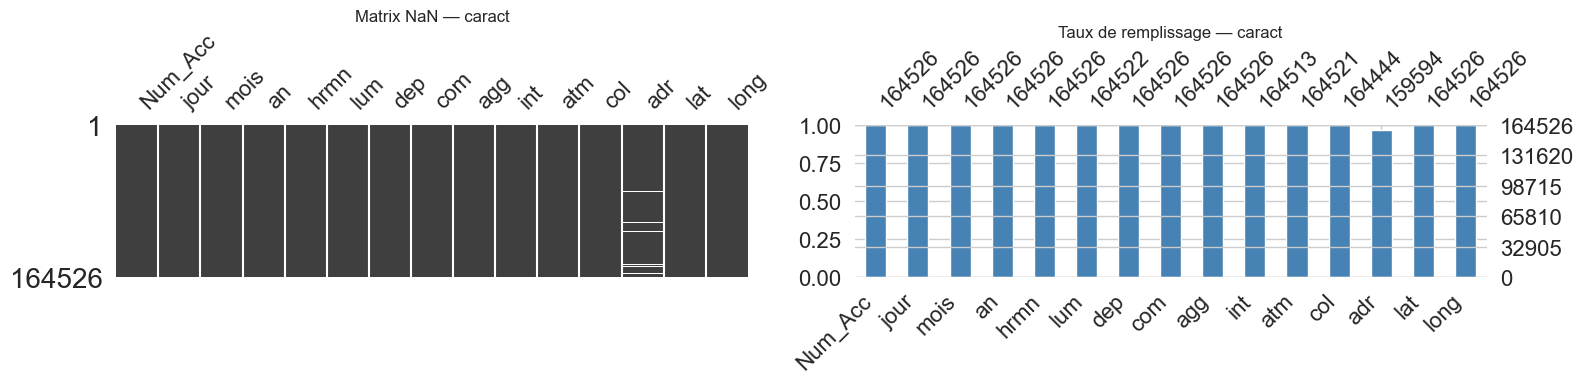


--- LIEUX ---


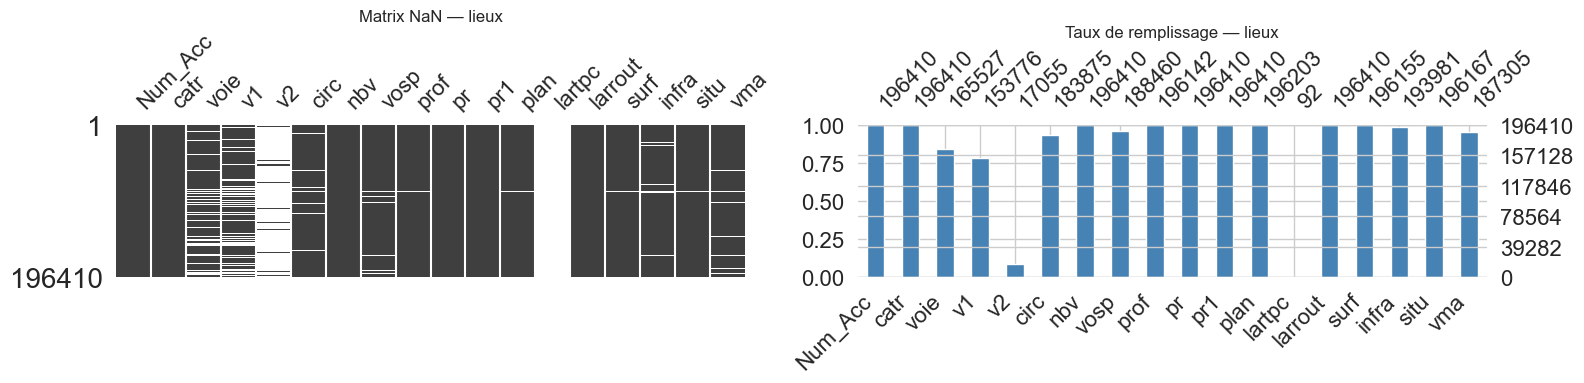


--- USAGERS ---


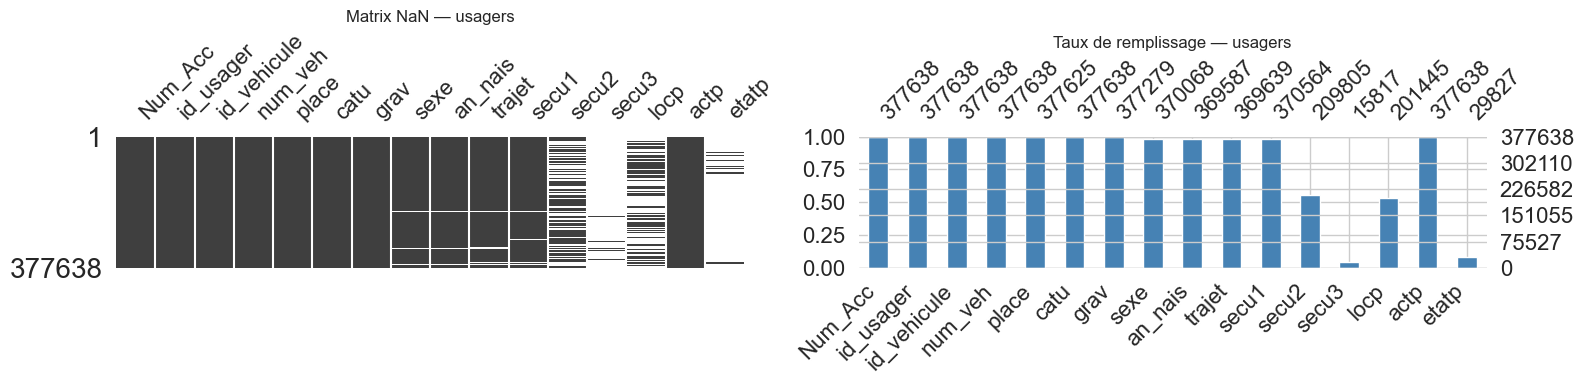


--- VEHICULES ---


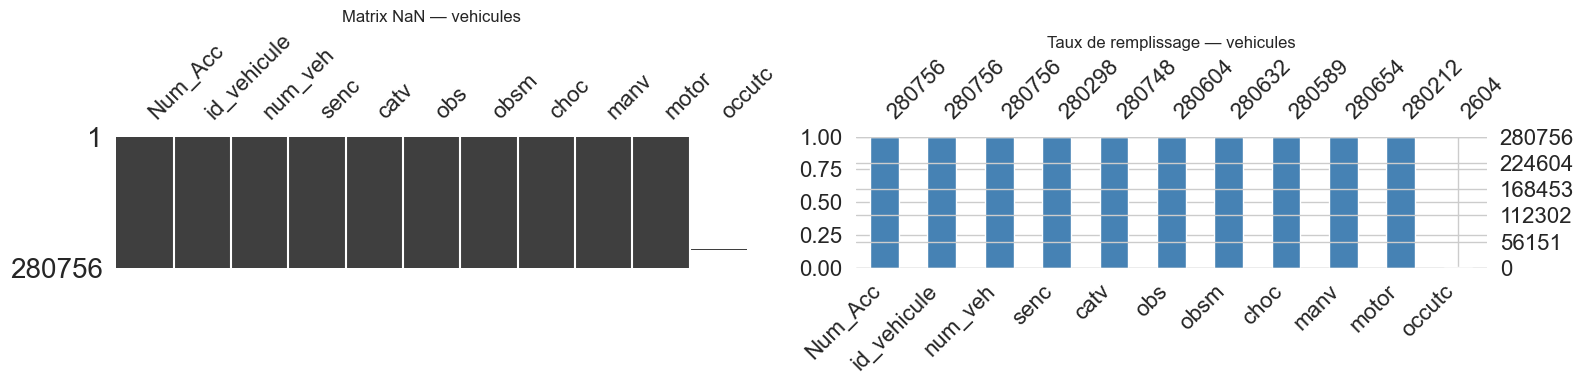

In [15]:
# missingno.matrix() montre les NaN sous forme visuelle
# les barres blanches = NaN, les barres grises = données présentes
for nom, df in [('caract',caract),('lieux',lieux),('usagers',usagers),('vehicules',vehicules)]:
    print(f'\n--- {nom.upper()} ---')
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    msno.matrix(df, ax=axes[0], sparkline=False)
    axes[0].set_title(f'Matrix NaN — {nom}')
    msno.bar(df, ax=axes[1], color='steelblue')
    axes[1].set_title(f'Taux de remplissage — {nom}')
    plt.tight_layout()
    plt.show()

> **Comment lire ces deux graphiques :**
>
> **Matrix (gauche)** — chaque ligne = une ligne de données, chaque colonne = une variable.
> Les cases **grises** = données présentes, les cases **blanches** = NaN.
> Ça permet de voir les **patterns** : est-ce que les mêmes lignes ont toujours des NaN ensemble ?
>
> **Bar chart (droite)** — chaque barre = une colonne. La hauteur = le % de valeurs **présentes**.
> Le chiffre au-dessus = le nombre exact de valeurs non-nulles.
> Barre pleine = aucun NaN. Barre à moitié = 50% de NaN.

> **Observations — graphiques missingno**
>
> **CARACT**
> La matrix montre que presque toutes les colonnes sont complètes (tout gris).
> Seule `adr` a des cases blanches — normal, elle n'est renseignée qu'en agglomération.
> Le bar chart confirme : `adr` est la seule colonne incomplète (164 444 valeurs sur 164 526).
> `lat` et `long` sont bien remplies — les accidents sont géolocalisés.
>
> **LIEUX**
> La matrix montre clairement 3 zones blanches : `voie`/`v1`/`v2` à gauche,
> `pr`/`pr1` au milieu, et `lartpc` à droite.
> Le bar chart confirme : `v2` est quasi vide (17 055 valeurs sur 196 410),
> `circ` a une barre basse aussi.
> `lartpc` a une barre à ~50% et `larrout` est bien remplie.
>
> **USAGERS**
> La matrix montre des colonnes très striées à droite : `secu2`, `secu3`, `locp`, `actp`, `etatp`.
> Le bar chart confirme : `secu3` et `etatp` sont quasi vides (15 817 et 29 827 valeurs sur 377 638),
> `locp` et `actp` sont à ~ 50%.
> `secu1`, `trajet`, `sexe`, `an_nais` ont de légères baisses (~370 000 valeurs) — ce sont
> les usagers en fuite depuis 2021 mentionnés dans la doc BAAC.
>
> **VEHICULES**
> La matrix est quasi entièrement grise — les données sont bien remplies.
> Le bar chart confirme : toutes les colonnes sont proches de 280 756 sauf `occutc`
> qui est quasi vide (2 604 valeurs sur 280 756) — uniquement les accidents de bus/tramway.

### 4.5 Suppression des doublons stricts (lignes 100% identiques)

In [16]:
# avant de supprimer je regarde combien il y en a
for nom, df in [('caract',caract),('lieux',lieux),('usagers',usagers),('vehicules',vehicules)]:
    nb = df.duplicated().sum()
    print(f'[{nom}] {nb} doublons stricts (lignes 100% identiques)')

[caract] 0 doublons stricts (lignes 100% identiques)
[lieux] 2 doublons stricts (lignes 100% identiques)
[usagers] 0 doublons stricts (lignes 100% identiques)
[vehicules] 0 doublons stricts (lignes 100% identiques)


In [17]:
# je regarde à quoi ressemblent les 2 lignes en doublon dans lieux
lieux[lieux.duplicated(keep=False)]

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
142046,202400012279,3,NaN,NaN,NaN,2.0,-1,NaN,2.0,-1,-1,1.0,NaN,-1,1.0,0.0,1.0,NaN
142047,202400012279,3,NaN,NaN,NaN,2.0,-1,NaN,2.0,-1,-1,1.0,NaN,-1,1.0,0.0,1.0,NaN
183504,202400044389,4,NaN,NaN,NaN,2.0,-1,NaN,1.0,-1,-1,1.0,NaN,-1,1.0,0.0,1.0,NaN
183505,202400044389,4,NaN,NaN,NaN,2.0,-1,NaN,1.0,-1,-1,1.0,NaN,-1,1.0,0.0,1.0,NaN


In [18]:
# je supprime uniquement les lignes 100% identiques
# je ne supprime PAS sur la base de Num_Acc seul
# car plusieurs usagers ou vehicules peuvent avoir le meme Num_Acc — c'est normal
caract    = caract.drop_duplicates().reset_index(drop=True)
lieux     = lieux.drop_duplicates().reset_index(drop=True)
usagers   = usagers.drop_duplicates().reset_index(drop=True)
vehicules = vehicules.drop_duplicates().reset_index(drop=True)

for nom, df in [('caract',caract),('lieux',lieux),('usagers',usagers),('vehicules',vehicules)]:
    print(f'[{nom}] {len(df):,} lignes après dédoublonnage')

[caract] 164,526 lignes après dédoublonnage
[lieux] 196,408 lignes après dédoublonnage
[usagers] 377,638 lignes après dédoublonnage
[vehicules] 280,756 lignes après dédoublonnage


### 4.6 Correction des types de données

In [19]:
# certaines colonnes sont lues comme texte alors qu'elles devraient être numériques
# pd.to_numeric avec errors='coerce' convertit et met NaN si la conversion échoue

cols_caract   = ['jour','mois','an','lum','dep','agg','int','atm','col']
cols_usagers  = ['grav','catu','sexe','trajet','an_nais']
cols_lieux    = ['catr','circ','nbv','surf','vma','prof','plan']
cols_veh      = ['catv','choc','manv','motor']

for col in cols_caract:
    if col in caract.columns: caract[col] = pd.to_numeric(caract[col], errors='coerce')
for col in cols_usagers:
    if col in usagers.columns: usagers[col] = pd.to_numeric(usagers[col], errors='coerce')
for col in cols_lieux:
    if col in lieux.columns: lieux[col] = pd.to_numeric(lieux[col], errors='coerce')
for col in cols_veh:
    if col in vehicules.columns: vehicules[col] = pd.to_numeric(vehicules[col], errors='coerce')

print('types corrigés')

types corrigés


### 4.7 Correction des coordonnées GPS

In [20]:
# je remplace la virgule par un point puis je convertis en float
caract['lat']  = caract['lat'].astype(str).str.replace(',', '.', regex=False)
caract['long'] = caract['long'].astype(str).str.replace(',', '.', regex=False)
caract['lat']  = pd.to_numeric(caract['lat'],  errors='coerce')
caract['long'] = pd.to_numeric(caract['long'], errors='coerce')

print(f"lat  : {caract['lat'].dtype}  | exemple : {caract['lat'].dropna().iloc[0]}")
print(f"long : {caract['long'].dtype} | exemple : {caract['long'].dropna().iloc[0]}")

lat  : float64  | exemple : 44.55942
long : float64 | exemple : 4.72572


In [21]:
# je garde uniquement la France métropolitaine
# les DOM-TOM ont des coordonnées en dehors de ces bornes
# lat entre 41 et 51, long entre -5 et 10
avant = len(caract)
caract = caract[
    caract['lat'].between(41, 51) &
    caract['long'].between(-5, 10)
].reset_index(drop=True)

print(f'Lignes supprimées (DOM-TOM) : {avant - len(caract):,}')
print(f'Lignes restantes : {len(caract):,}')

Lignes supprimées (DOM-TOM) : 9,578
Lignes restantes : 154,948


### 4.8 Suppression des colonnes inutiles

Avant de supprimer, je regarde le taux de NaN et je justifie chaque décision à partir de la doc BAAC.

In [22]:
# je regarde le % de NaN pour chaque colonne
for nom, df in [('caract',caract),('lieux',lieux),('usagers',usagers),('vehicules',vehicules)]:
    print(f'\n--- {nom.upper()} ---')
    pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    print(pct[pct > 0].round(1).to_string())


--- CARACT ---
adr    3.2
dep    1.2
col    0.0
int    0.0
atm    0.0
lum    0.0

--- LIEUX ---
lartpc    100.0
v2         91.3
v1         21.7
voie       15.7
circ        6.4
vma         4.6
vosp        4.0
infra       1.2
prof        0.1
surf        0.1
situ        0.1
plan        0.1
nbv         0.1

--- USAGERS ---
secu3      95.8
etatp      92.1
locp       46.7
secu2      44.4
an_nais     2.1
trajet      2.1
sexe        2.0
secu1       1.9
grav        0.1
place       0.0

--- VEHICULES ---
occutc    99.1
motor      0.2
senc       0.2
choc       0.1
obs        0.1
obsm       0.0
manv       0.0
catv       0.0


> **Décisions de suppression — justifiées colonne par colonne**
>
> **TABLE CARACT**
> - `adr` supprimée : adresse postale en texte libre, impossible à utiliser dans un modèle ML
> - `com` supprimée : code commune INSEE — 35 000 modalités différentes, trop granulaire pour un modèle
> - `dep` gardée : département — peut capter des effets régionaux sur l'accidentalité
> - `lat` / `long` gardées : coordonnées GPS — utiles pour la carte et le feature engineering
>
> **TABLE LIEUX**
> - `voie` supprimée : numéro de la route — pas de valeur prédictive, trop spécifique
> - `v1` supprimée : indice numérique de route (ex: "2 bis") — même raison, 22% de NaN en plus
> - `v2` supprimée : indice alphanumérique de route — quasi vide (17 055 valeurs sur 196 410)
> - `pr`, `pr1` supprimées : numéro de borne kilométrique et distance — aucune valeur prédictive
> - `lartpc` supprimée : largeur du terre-plein central — 100% NaN, pas exploitable
> - `larrout` gardée : largeur de la chaussée — indicateur indirect du type de route
> - `vosp` gardée : existence d'une voie réservée — pertinent pour les accidents impliquant des cyclistes
> - `circ` gardée : régime de circulation (sens unique, bidirectionnel...) — informatif
> - `vma` gardée : vitesse maximale autorisée — très prédictif de la gravité
>
> **TABLE USAGERS**
> - `num_Veh` supprimée : doublon alphanumérique de `id_vehicule` — pas de NaN mais inutile
> - `secu2` supprimée : 2e équipement de sécurité — 44% NaN, `secu1` suffit
> - `secu3` supprimée : 3e équipement de sécurité — 96% NaN, quasi vide
> - `locp` supprimée : localisation du piéton — 47% NaN, renseignée uniquement pour les piétons
> - `actp` supprimée : action du piéton — quasi vide, même raison
> - `etatp` supprimée : état du piéton — 92% NaN, même raison
>
> **TABLE VEHICULES**
> - `Num_Veh` supprimée : doublon alphanumérique de `id_vehicule` — pas de NaN mais inutile
> - `occutc` supprimée : occupants transport en commun — 99% NaN, uniquement les rares accidents de bus/tramway
> - `obs`, `obsm` gardées : obstacle fixe et mobile heurté — directement lié à la gravité, peu de NaN

In [23]:
# CARACT
for col in ['adr','com']:
    if col in caract.columns:
        caract.drop(columns=[col], inplace=True)
        print(f'[caract] supprimee : {col}')

# LIEUX
for col in ['voie','v1','v2','pr','pr1', 'lartpc']:
    if col in lieux.columns:
        lieux.drop(columns=[col], inplace=True)
        print(f'[lieux] supprimee : {col}')

# USAGERS
for col in ['secu2','secu3','locp','actp','etatp','num_veh']:
    if col in usagers.columns:
        usagers.drop(columns=[col], inplace=True)
        print(f'[usagers] supprimee : {col}')

# VEHICULES
for col in ['occutc','num_veh']:
    if col in vehicules.columns:
        vehicules.drop(columns=[col], inplace=True)
        print(f'[vehicules] supprimee : {col}')

[caract] supprimee : adr
[caract] supprimee : com
[lieux] supprimee : voie
[lieux] supprimee : v1
[lieux] supprimee : v2
[lieux] supprimee : pr
[lieux] supprimee : pr1
[lieux] supprimee : lartpc
[usagers] supprimee : secu2
[usagers] supprimee : secu3
[usagers] supprimee : locp
[usagers] supprimee : actp
[usagers] supprimee : etatp
[usagers] supprimee : num_veh
[vehicules] supprimee : occutc
[vehicules] supprimee : num_veh


In [24]:
# je verifie ce qu'il reste
for nom, df in [('caract',caract),('lieux',lieux),('usagers',usagers),('vehicules',vehicules)]:
    print(f'[{nom}] {df.shape[1]} colonnes : {list(df.columns)}')

[caract] 13 colonnes : ['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'agg', 'int', 'atm', 'col', 'lat', 'long']
[lieux] 12 colonnes : ['Num_Acc', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'larrout', 'surf', 'infra', 'situ', 'vma']
[usagers] 10 colonnes : ['Num_Acc', 'id_usager', 'id_vehicule', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1']
[vehicules] 9 colonnes : ['Num_Acc', 'id_vehicule', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor']


### 4.9 Traitement des NaN

**Stratégie appliquée :**
- **Suppression des lignes** si le volume est négligeable (< 0.05%) ou si c'est la variable cible (`grav`)
- **Mode** pour les colonnes catégorielles — la valeur la plus fréquente est représentative de la situation la plus courante
- **Médiane** pour les colonnes numériques — plus robuste que la moyenne face aux valeurs extrêmes

> **Pourquoi pas une catégorie "Inconnu" ?**
> Dans les BAAC, les NaN signifient "non renseigné par les forces de l'ordre sur le terrain" — pas une valeur métier.
> Les catégories "aucun équipement" (secu1=0) ou "sans obstacle" (obs=0) existent déjà dans les données.
> Un NaN ne représente donc pas une nouvelle catégorie mais une absence d'information.

In [25]:
# ── CARACT : suppression (< 0.05% du dataset, négligeable) ──────
avant = len(caract)
caract = caract.dropna(subset=['col', 'int', 'atm', 'lum', 'dep'])
print(f'caract    — lignes supprimées : {avant - len(caract):,}')

# ── LIEUX : mode pour catégorielles, médiane pour numériques ─────
cols_mode_lieux = ['circ', 'vosp', 'infra', 'prof', 'surf', 'situ', 'plan']
for col in cols_mode_lieux:
    lieux[col] = lieux[col].fillna(lieux[col].mode()[0])

lieux['vma'] = lieux['vma'].fillna(lieux['vma'].median())  # numérique → médiane
lieux['nbv'] = lieux['nbv'].fillna(lieux['nbv'].median())  # numérique → médiane
print(f'lieux     — NaN traités')

# ── USAGERS : suppression pour grav et sexe, mode/médiane pour le reste ──
avant = len(usagers)
usagers = usagers.dropna(subset=['grav'])   # variable cible — aucune alternative
print(f'usagers   — lignes supprimées (grav) : {avant - len(usagers):,}')

avant = len(usagers)
usagers = usagers.dropna(subset=['sexe'])   # essentiel pour l'analyse des biais
print(f'usagers   — lignes supprimées (sexe) : {avant - len(usagers):,}')

usagers['an_nais'] = usagers['an_nais'].fillna(usagers['an_nais'].median())  # numérique → médiane

for col in ['trajet', 'secu1', 'place']:    # catégorielles → mode
    usagers[col] = usagers[col].fillna(usagers[col].mode()[0])
print(f'usagers   — NaN traités')

# ── VEHICULES : toutes catégorielles → mode ──────────────────────
for col in ['motor', 'senc', 'choc', 'obs', 'obsm', 'manv', 'catv']:
    vehicules[col] = vehicules[col].fillna(vehicules[col].mode()[0])
print(f'vehicules — NaN traités')

# ── Vérification finale ──────────────────────────────────────────
print()
print('Vérification — NaN restants par table :')
for nom, table in [('caract', caract), ('lieux', lieux), ('usagers', usagers), ('vehicules', vehicules)]:
    total_nan = table.isnull().sum().sum()
    print(f'  {nom:<12} : {total_nan} NaN restants')

caract    — lignes supprimées : 1,894
lieux     — NaN traités
usagers   — lignes supprimées (grav) : 359
usagers   — lignes supprimées (sexe) : 7,214
usagers   — NaN traités
vehicules — NaN traités

Vérification — NaN restants par table :
  caract       : 0 NaN restants
  lieux        : 0 NaN restants
  usagers      : 0 NaN restants
  vehicules    : 0 NaN restants


> **Résultat :** toutes les tables sont propres avant le merge.
> Le dataset fusionné sera prêt pour la modélisation sans traitement NaN supplémentaire.

### 4.10 Résumé du nettoyage

In [26]:
print('=' * 55)
print('  RÉSUMÉ APRÈS NETTOYAGE')
print('=' * 55)
for nom, df in [('caract',caract),('lieux',lieux),('usagers',usagers),('vehicules',vehicules)]:
    pct_nan = df.isnull().mean().mean() * 100
    print(f'  {nom:<12}: {len(df):>8,} lignes | {df.shape[1]} colonnes | NaN moy : {pct_nan:.1f}%')
print('=' * 55)

  RÉSUMÉ APRÈS NETTOYAGE
  caract      :  153,054 lignes | 13 colonnes | NaN moy : 0.0%
  lieux       :  196,408 lignes | 12 colonnes | NaN moy : 0.0%
  usagers     :  370,065 lignes | 10 colonnes | NaN moy : 0.0%
  vehicules   :  280,756 lignes | 9 colonnes | NaN moy : 0.0%


<a id='5-merge'></a>
## 5. Merge — fusion en un seul dataset

La clé de liaison entre toutes les tables c'est `Num_Acc`.  
J'utilise des **left joins** pour ne perdre aucune ligne.

---

In [27]:
# caract + lieux : 1 accident = 1 lieu (jointure 1-1)
df = caract.merge(lieux, on='Num_Acc', how='left', suffixes=('','_lieux'))
print(f'caract + lieux    : {len(df):,} lignes | {df.shape[1]} colonnes')

caract + lieux    : 183,530 lignes | 24 colonnes


In [28]:
# + usagers : 1 accident peut avoir plusieurs usagers (jointure 1-N)
df = df.merge(usagers, on='Num_Acc', how='left', suffixes=('','_usager'))
print(f'+ usagers         : {len(df):,} lignes | {df.shape[1]} colonnes')
print('  → normal que ça grossisse : 1 accident = plusieurs usagers')

+ usagers         : 413,570 lignes | 33 colonnes
  → normal que ça grossisse : 1 accident = plusieurs usagers


In [29]:
# + vehicules : jointure sur Num_Acc + id_vehicule
df = df.merge(vehicules, on=['Num_Acc','id_vehicule'], how='left', suffixes=('','_veh'))
print(f'+ vehicules       : {len(df):,} lignes | {df.shape[1]} colonnes')

+ vehicules       : 413,570 lignes | 40 colonnes


In [30]:
# je supprime les lignes sans gravité (grav non renseignée = inutilisable pcq c la target)
avant = len(df)
df = df[df['grav'].notna()].reset_index(drop=True)
print(f'{avant - len(df):,} lignes sans gravité supprimées')
print(f'Dataset final     : {len(df):,} lignes | {df.shape[1]} colonnes')

0 lignes sans gravité supprimées
Dataset final     : 413,570 lignes | 40 colonnes


In [31]:
# aperçu du dataset final
df.head(3)

,Num_Acc,jour,mois,an,hrmn,lum,dep,agg,int,atm,col,lat,long,catr,circ,nbv,vosp,prof,plan,larrout,surf,infra,situ,vma,id_usager,id_vehicule,place,catu,grav,sexe,an_nais,trajet,secu1,senc,catv,obs,obsm,choc,manv,motor
0,202200000001,19,10,2022,16:15,1.0,26.0,2,3.0,1.0,3.0,44.55942,4.72572,4,2.0,2.0,0.0,1.0,1.0,-1,1.0,0.0,1.0,50.0,1 099 700,813 952,1.0,1,3.0,1.0,2008.0,5.0,2.0,1.0,2.0,0.0,2.0,1.0,9.0,1.0
1,202200000001,19,10,2022,16:15,1.0,26.0,2,3.0,1.0,3.0,44.55942,4.72572,4,2.0,2.0,0.0,1.0,1.0,-1,1.0,0.0,1.0,50.0,1 099 701,813 953,1.0,1,1.0,1.0,1948.0,5.0,1.0,1.0,7.0,0.0,2.0,2.0,1.0,1.0
2,202200000002,20,10,2022,08:34,1.0,25.0,2,3.0,1.0,3.0,46.92581,6.34620,4,2.0,2.0,0.0,1.0,1.0,-1,1.0,0.0,1.0,50.0,1 099 698,813 950,1.0,1,4.0,1.0,1988.0,9.0,1.0,2.0,7.0,0.0,2.0,8.0,15.0,1.0


### 5.1 Création des variables dérivées

Ces colonnes sont calculées à partir des données brutes — c'est du nettoyage, pas de la modélisation.
`hrmn`, `an_nais`, `jour`, `mois`, `an` bruts sont difficilement utilisables directement par un modèle.

In [32]:
# age : an - an_nais
df['age'] = df['an'] - df['an_nais']
# je supprime les ages aberrants
df.loc[df['age'] < 0, 'age'] = np.nan
df.loc[df['age'] > 110, 'age'] = np.nan
print(f"age — min: {df['age'].min():.0f} | max: {df['age'].max():.0f} | NaN: {df['age'].isna().sum():,}")

# heure : extraite de hrmn (format '07:40')
df['heure'] = df['hrmn'].astype(str).str.replace(':', '').str[:2]
df['heure'] = pd.to_numeric(df['heure'], errors='coerce')
df.loc[~df['heure'].between(0, 23), 'heure'] = np.nan
print(f"heure — valeurs uniques : {sorted(df['heure'].dropna().unique().astype(int).tolist()[:5])}...")

# jour_semaine : 0=Lundi ... 6=Dimanche
df['date'] = pd.to_datetime(
    df['an'].astype(str) + '-' + df['mois'].astype(str) + '-' + df['jour'].astype(str),
    errors='coerce'
)
df['jour_semaine'] = df['date'].dt.dayofweek
df['weekend'] = df['jour_semaine'].isin([5, 6]).astype(int)
df.drop(columns=['date'], inplace=True)

print(f"jour_semaine — distribution :")
print(df['jour_semaine'].value_counts().sort_index().to_string())

age — min: 0 | max: 110 | NaN: 0
heure — valeurs uniques : [8, 11, 16, 17, 18]...
jour_semaine — distribution :
jour_semaine
0    55747
1    58494
2    59395
3    59017
4    67505
5    61481
6    51931


<a id='6-visualisations'></a>
## 6. Visualisations

---

In [33]:
import os
# je crée le dossier visualisations s'il n'existe pas
os.makedirs('./visualisations', exist_ok=True)
print('Dossier visualisations prêt')

Dossier visualisations prêt


### 6.1 Distribution de la variable cible `grav`

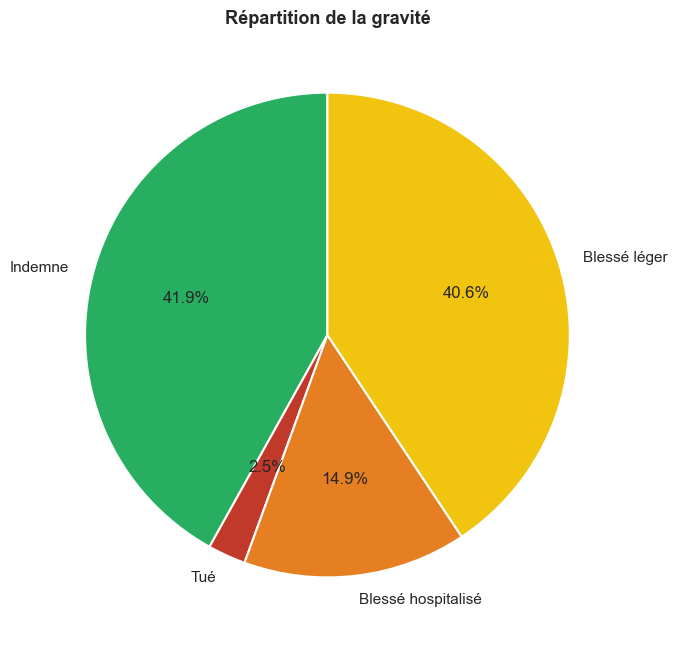

In [34]:
counts = df['grav'].value_counts().sort_index()

labels_grav = {1:'Indemne', 2:'Tué', 3:'Blessé hospitalisé', 4:'Blessé léger'}
couleurs    = {1:'#27ae60', 2:'#c0392b', 3:'#e67e22', 4:'#f1c40f'}

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts.values,
       labels=[labels_grav[k] for k in counts.index],
       colors=[couleurs[k] for k in counts.index],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Répartition de la gravité', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Observations :** classes très déséquilibrées. Les indemnes et blessés légers dominent largement.  
> Il faudra gérer ce déséquilibre lors de la modélisation (SMOTE, class_weight...).

### 6.2 Évolution des accidents par année

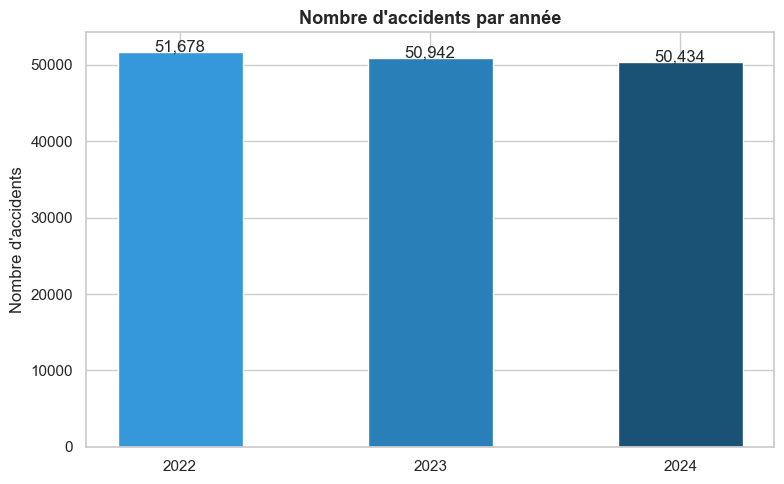

In [35]:
# je compte les accidents uniques par année (1 Num_Acc = 1 accident)
acc_an = df.groupby('an')['Num_Acc'].nunique()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(acc_an.index.astype(str), acc_an.values, color=['#3498db','#2980b9','#1a5276'], width=0.5, edgecolor='white')
ax.set_title("Nombre d'accidents par année", fontsize=13, fontweight='bold')
ax.set_ylabel("Nombre d'accidents")
for b in ax.patches:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50, f'{int(b.get_height()):,}', ha='center')
plt.tight_layout()
plt.savefig('./visualisations/viz_02_accidents_par_annee.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :** le nombre d'accidents est relativement stable sur les 3 années.
> Une légère variation peut s'expliquer par les changements de comportement post-covid
> ou les conditions météo d'une année à l'autre.

### 6.3 Accidents par heure de la journée

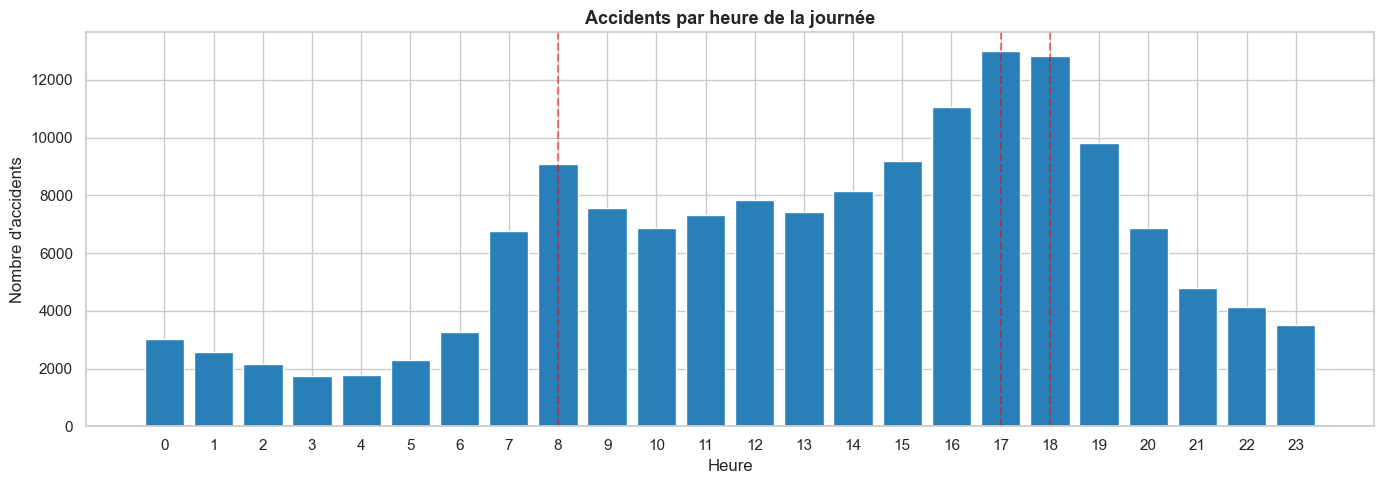

Heure de pointe : 17.0h (13,001 accidents)


In [36]:
# j'extrais l'heure depuis la colonne hrmn (format '07:40')

acc_heure = df[df['heure'].between(0,23)].groupby('heure')['Num_Acc'].nunique()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(acc_heure.index, acc_heure.values, color='#2980b9', edgecolor='white')
ax.set_title("Accidents par heure de la journée", fontsize=13, fontweight='bold')
ax.set_xlabel('Heure'); ax.set_ylabel("Nombre d'accidents")
ax.set_xticks(range(24))
for h in [8, 17, 18]:
    ax.axvline(x=h, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('./visualisations/viz_03_accidents_par_heure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Heure de pointe : {acc_heure.idxmax()}h ({acc_heure.max():,} accidents)")

> **Observations :** deux pics clairement visibles — le matin vers 8h (heure de pointe)
> et surtout le soir entre 17h et 19h. La nuit entre 2h et 5h c'est le creux.
> Ce pattern confirme que l'heure est une variable pertinente pour le modèle.

### 6.4 Taux de mortalité par condition météo

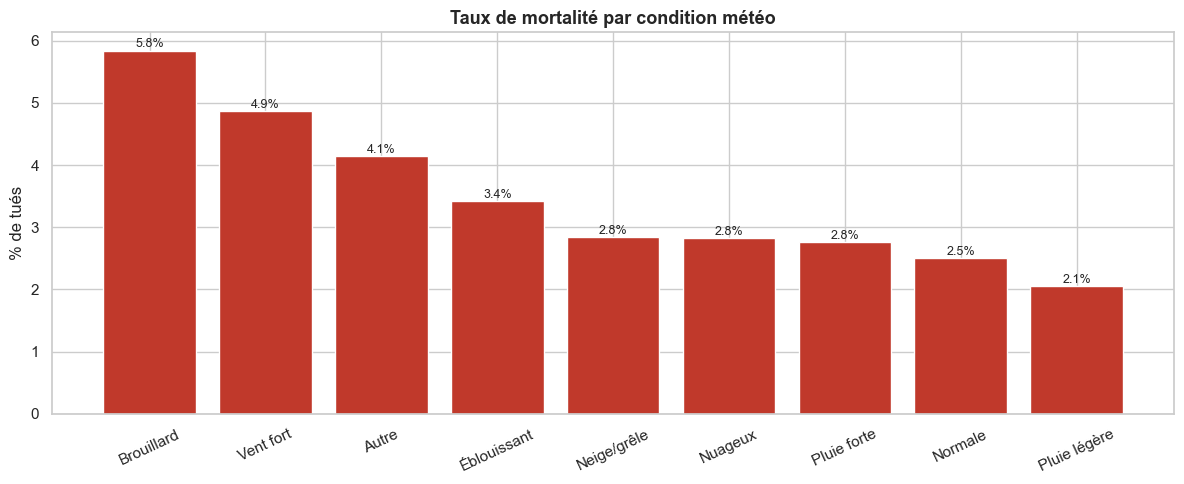

In [37]:
labels_atm = {1:'Normale',2:'Pluie légère',3:'Pluie forte',4:'Neige/grêle',
              5:'Brouillard',6:'Vent fort',7:'Éblouissant',8:'Nuageux',9:'Autre'}

meteo = df[['atm','grav']].dropna()
meteo = meteo[meteo['atm'].isin(labels_atm) & meteo['grav'].isin([1,2,3,4])].copy()
meteo['atm_label'] = meteo['atm'].map(labels_atm)

# taux de tués (grav=2) pour chaque météo
taux = meteo.groupby('atm_label')['grav'].apply(lambda x: (x==2).sum()/len(x)*100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(taux.index, taux.values, color='#c0392b', edgecolor='white')
ax.set_title('Taux de mortalité par condition météo', fontsize=13, fontweight='bold')
ax.set_ylabel('% de tués')
ax.tick_params(axis='x', rotation=25)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'{b.get_height():.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('./visualisations/viz_04_mortalite_par_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :** contre-intuitivement, c'est par temps normal que le taux de mortalité
> est le plus bas. Le brouillard, la neige et le vent fort sont associés à plus de décès.
> Attention : il y a aussi beaucoup moins d'accidents par mauvais temps — les gens roulent moins.

### 6.5 Gravité par luminosité

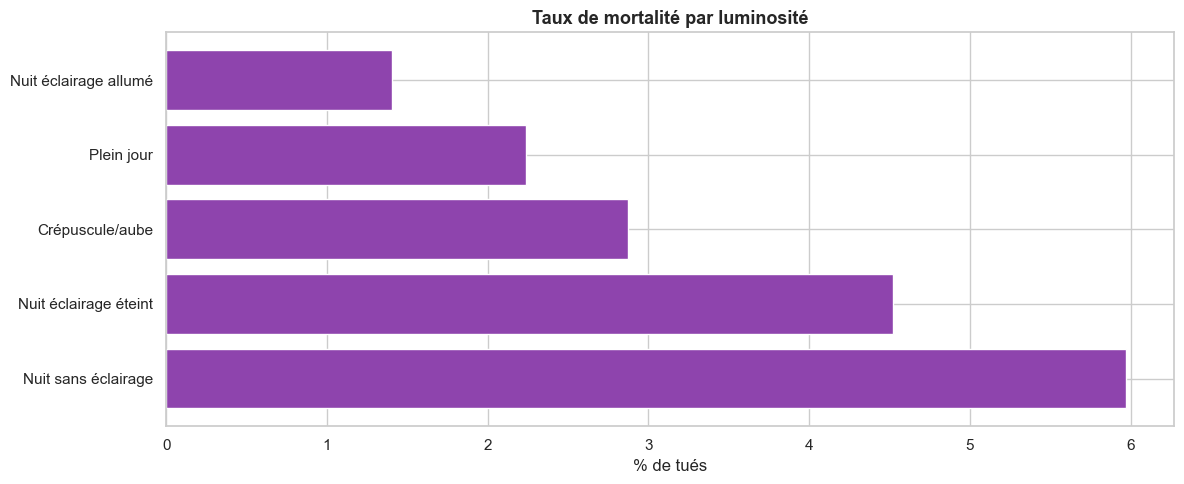

In [38]:
labels_lum = {1:'Plein jour',2:'Crépuscule/aube',3:'Nuit sans éclairage',
              4:'Nuit éclairage éteint',5:'Nuit éclairage allumé'}

lum = df[['lum','grav']].dropna()
lum = lum[lum['lum'].isin(labels_lum) & lum['grav'].isin([1,2,3,4])].copy()
lum['lum_label'] = lum['lum'].map(labels_lum)

taux_lum = lum.groupby('lum_label')['grav'].apply(lambda x: (x==2).sum()/len(x)*100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(taux_lum.index, taux_lum.values, color='#8e44ad', edgecolor='white')
ax.set_title('Taux de mortalité par luminosité', fontsize=13, fontweight='bold')
ax.set_xlabel('% de tués')
plt.tight_layout()
plt.savefig('./visualisations/viz_05_mortalite_par_luminosite.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :** la nuit sans éclairage public est la condition la plus mortelle.
> Le plein jour a le taux de mortalité le plus bas malgré le plus grand nombre d'accidents.
> La luminosité est donc une variable très pertinente pour prédire la gravité.

### 6.6 Répartition par sexe

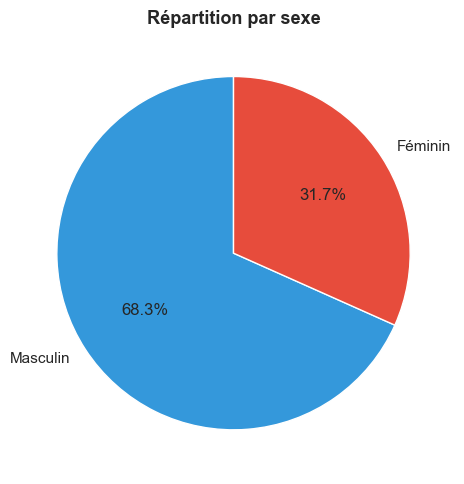

In [39]:
# sexe : 1=Masculin, 2=Féminin
sexe_counts = df['sexe'].value_counts()
labels_sexe = {1:'Masculin', 2:'Féminin'}

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(sexe_counts.values,
       labels=[labels_sexe.get(k, str(k)) for k in sexe_counts.index],
       colors=['#3498db','#e74c3c'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('Répartition par sexe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./visualisations/viz_06_repartition_par_sexe.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :** les hommes sont majoritaires dans les accidents (~75%).
> Cela reflète une exposition plus élevée : plus de km parcourus, plus de deux-roues.

### 6.7 Gravité par catégorie d'usager

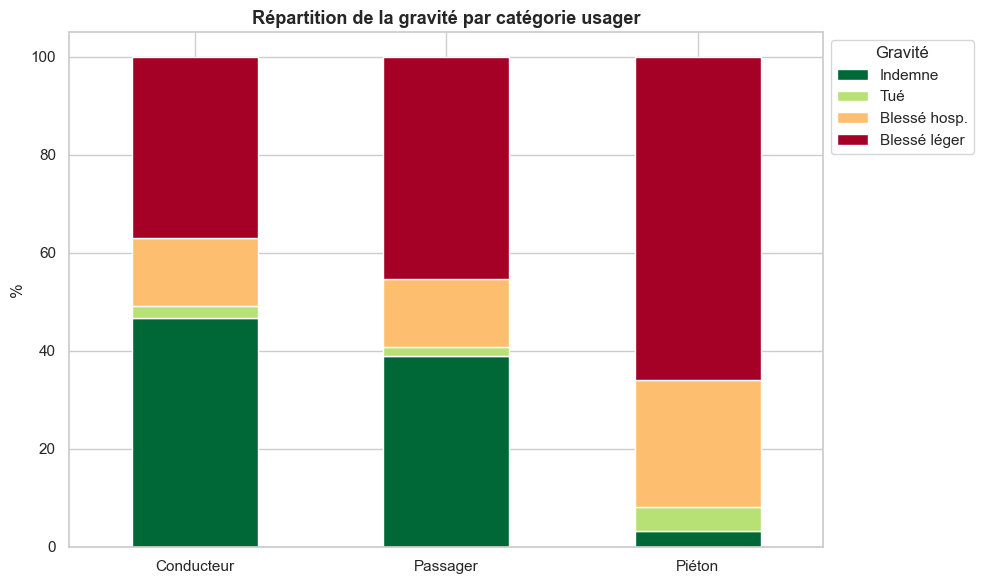

In [40]:
# catu : 1=Conducteur, 2=Passager, 3=Piéton
labels_catu = {1:'Conducteur', 2:'Passager', 3:'Piéton'}

catu_grav = df[df['catu'].isin([1,2,3]) & df['grav'].isin([1,2,3,4])].copy()
catu_grav['catu_label'] = catu_grav['catu'].map(labels_catu)

pivot = catu_grav.groupby(['catu_label','grav']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct.plot(kind='bar', stacked=True, colormap='RdYlGn_r', figsize=(10,6), edgecolor='white')
plt.title('Répartition de la gravité par catégorie usager', fontsize=13, fontweight='bold')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(title='Gravité', labels=['Indemne','Tué','Blessé hosp.','Blessé léger'], bbox_to_anchor=(1,1))
plt.xlabel('')
plt.tight_layout()
plt.savefig('./visualisations/viz_07_gravite_par_categorie_usager.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :** les piétons ont un profil de gravité très différent des conducteurs et passagers —
> beaucoup plus de blessés hospitalisés et de tués, et très peu d'indemnes.
> C'est logique : un piéton n'a aucune protection lors d'un choc.

### 6.8 Accidents par type de route

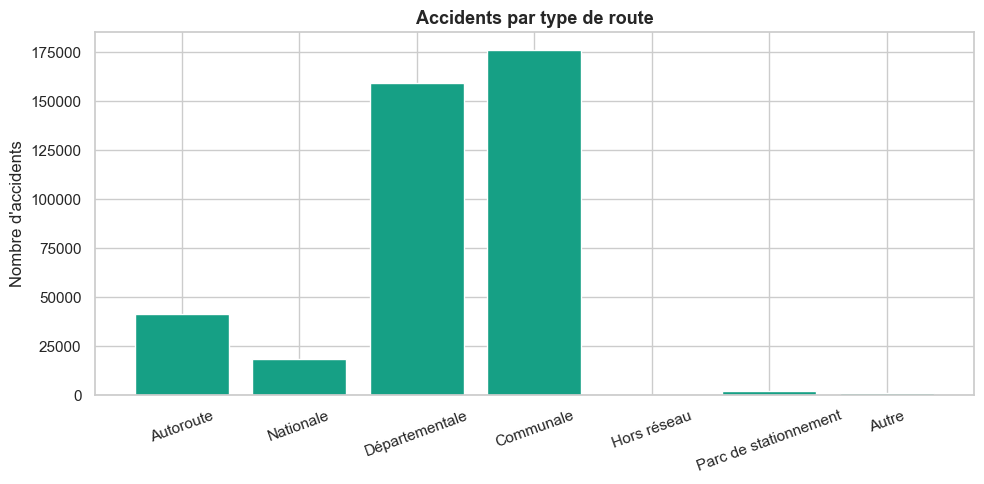

In [41]:
labels_catr = {1:'Autoroute',2:'Nationale',3:'Départementale',4:'Communale',5:'Hors réseau',6:'Parc de stationnement',9:'Autre'}

catr_counts = df[df['catr'].isin(labels_catr)]['catr'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([labels_catr.get(k,str(k)) for k in catr_counts.index], catr_counts.values,
       color='#16a085', edgecolor='white')
ax.set_title("Accidents par type de route", fontsize=13, fontweight='bold')
ax.set_ylabel("Nombre d'accidents")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('./visualisations/viz_08_accidents_par_type_route.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :** la majorité des accidents ont lieu sur les voies communales et départementales.
> Les autoroutes ont peu d'accidents en nombre mais les chocs y sont souvent plus graves
> à cause des vitesses élevées.

### 6.9 Heatmap — accidents par heure et jour de la semaine

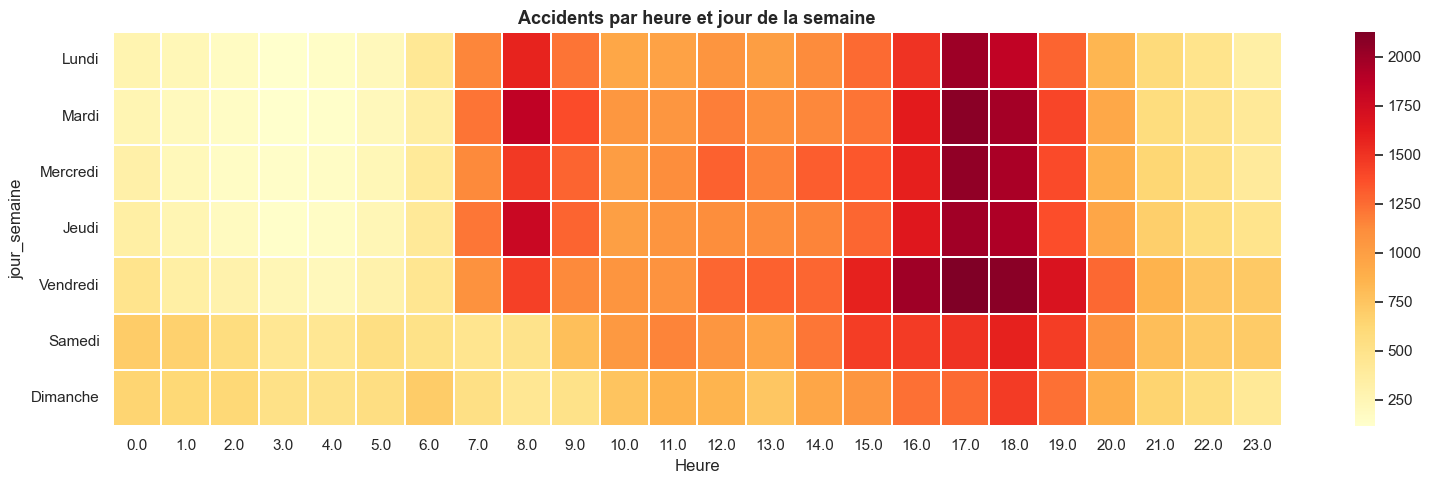

In [42]:
# jour_semaine est créé en 5.1 — je l'utilise directement
heatmap_data = df[df['heure'].between(0,23)].groupby(['jour_semaine','heure'])['Num_Acc'].nunique().unstack(fill_value=0)

jours = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_yticklabels(jours, rotation=0)
ax.set_title('Accidents par heure et jour de la semaine', fontsize=13, fontweight='bold')
ax.set_xlabel('Heure')
plt.tight_layout()
plt.savefig('./visualisations/viz_09_heatmap_heure_jour_semaine.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :** les cases les plus rouges sont le vendredi soir et le samedi entre 17h et 19h.
> Le dimanche matin entre 2h et 4h ressort aussi — probablement lié aux sorties nocturnes.
> La heatmap confirme que combiner heure et jour de la semaine est plus informatif que chaque variable seule.

### 6.10 Gravité par type de véhicule (top 8)

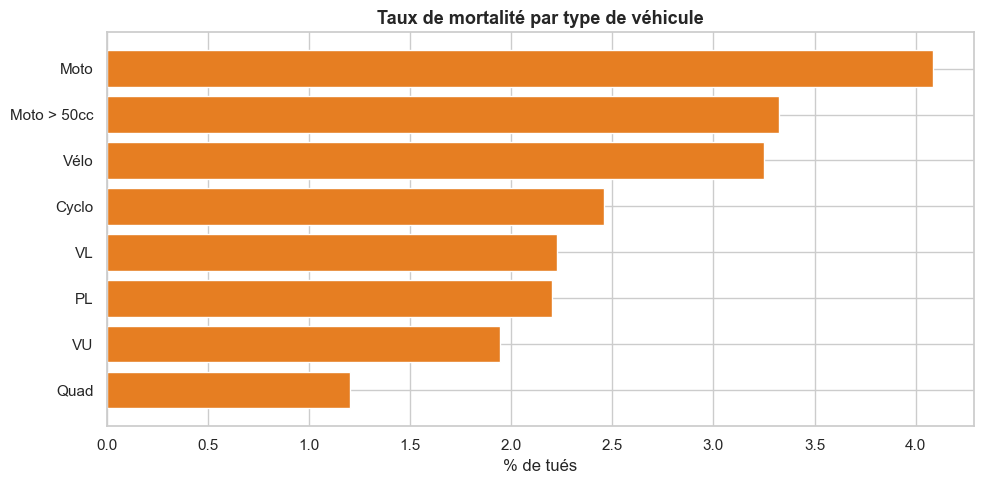

In [43]:
labels_catv = {1:'Vélo',2:'Cyclo',7:'VL',10:'VU',13:'PL',14:'Moto',15:'Moto > 50cc',30:'Quad'}

top_veh = df[df['catv'].isin(labels_catv)].copy()
top_veh['catv_label'] = top_veh['catv'].map(labels_catv)

taux_veh = top_veh.groupby('catv_label')['grav'].apply(lambda x: (x==2).sum()/len(x)*100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(taux_veh.index, taux_veh.values, color='#e67e22', edgecolor='white')
ax.set_title('Taux de mortalité par type de véhicule', fontsize=13, fontweight='bold')
ax.set_xlabel('% de tués')
plt.tight_layout()
plt.savefig('./visualisations/viz_10_mortalite_par_type_vehicule.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :** les deux-roues motorisés (motos, scooters) ont les taux de mortalité
> les plus élevés — jusqu'à 5 fois plus que les voitures.
> Le type de véhicule est donc une variable très prédictive de la gravité.

### 6.11 Accidents graves par sexe

Je regroupe les usagers en deux catégories : grave (tué ou hospitalisé) et non grave (blessé léger ou indemne).

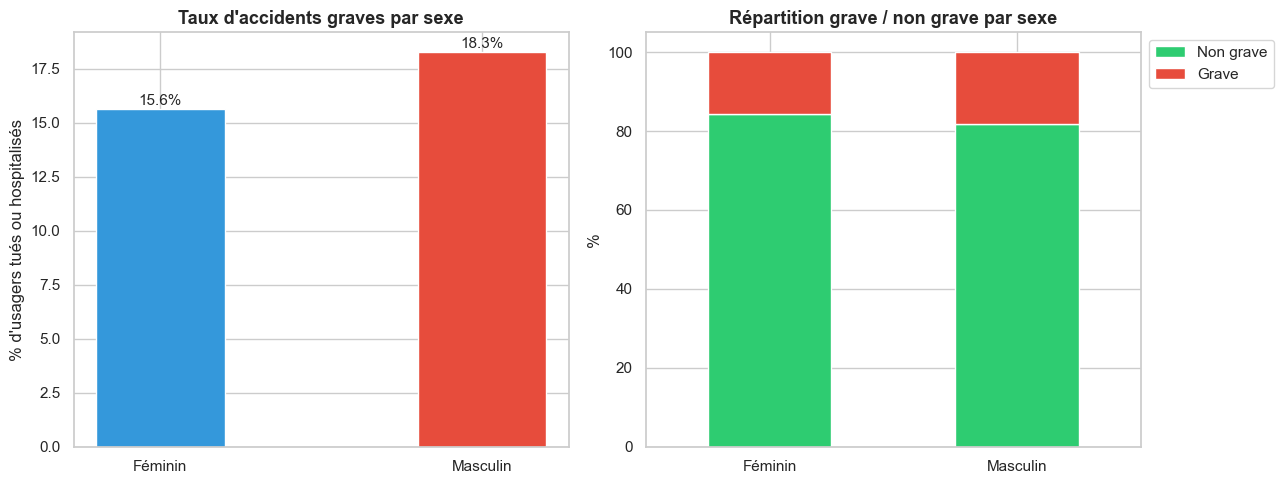

In [44]:
# je crée une variable temporaire pour cette visualisation
# je ne l'ajoute pas à df — grav_binaire sera définie dans le notebook 2
sexe_grave = df[df['sexe'].isin([1, 2])].copy()
sexe_grave['grave'] = sexe_grave['grav'].apply(lambda x: 1 if x in [2, 3] else 0)
sexe_grave['sexe_label'] = sexe_grave['sexe'].map({1:'Masculin', 2:'Féminin'})

taux_sexe = sexe_grave.groupby('sexe_label')['grave'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(taux_sexe.index, taux_sexe.values,
              color=['#3498db', '#e74c3c'], edgecolor='white', width=0.4)
ax.set_title('Taux d\'accidents graves par sexe', fontsize=13, fontweight='bold')
ax.set_ylabel('% d\'usagers tués ou hospitalisés')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
            f'{b.get_height():.1f}%', ha='center', fontsize=11)

ax2 = axes[1]
grave_counts = sexe_grave.groupby(['sexe_label','grave']).size().unstack(fill_value=0)
grave_pct = grave_counts.div(grave_counts.sum(axis=1), axis=0) * 100
grave_pct.plot(kind='bar', stacked=True, ax=ax2,
               color=['#2ecc71','#e74c3c'], edgecolor='white')
ax2.set_title('Répartition grave / non grave par sexe', fontsize=13, fontweight='bold')
ax2.set_ylabel('%')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(['Non grave', 'Grave'], bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('./visualisations/viz_12_accidents_graves_par_sexe.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :** on peut comparer ici le taux d'accidents graves entre hommes et femmes.
> Un accident est considéré grave s'il a entraîné une hospitalisation ou un décès.

### 6.12 Biais de représentation — Sexe

> **Problème :** en volume brut, les hommes semblent beaucoup plus accidentés que les femmes.
> Mais c'est parce qu'ils conduisent davantage, pas forcément parce qu'ils conduisent moins bien.
>
> **Solution :** comparer le **taux** d'accidents graves (pour 100 accidents), pas le volume.

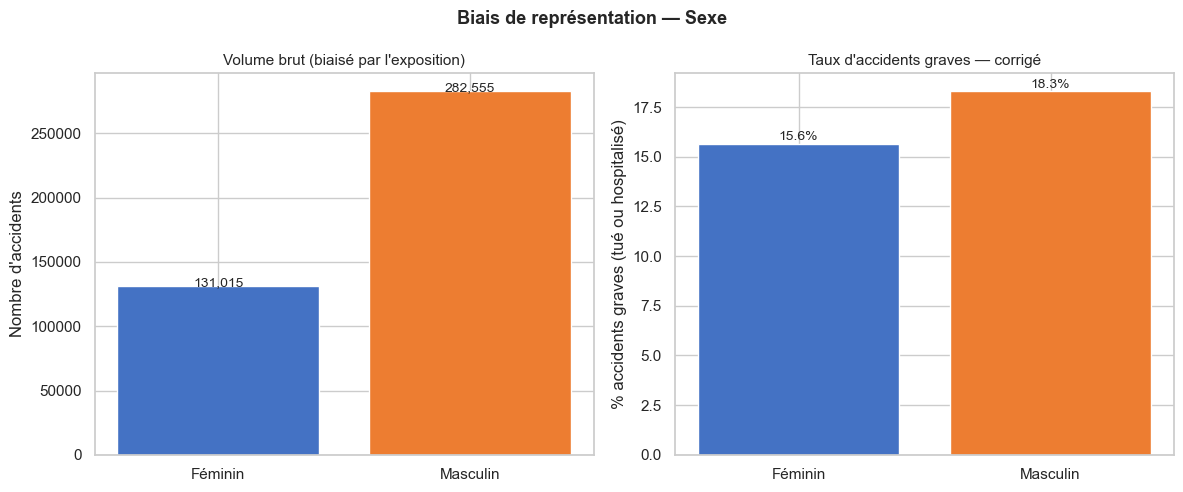

sexe_label  nb_accidents  taux_grave
   Féminin        131015   15.625692
  Masculin        282555   18.279981


In [45]:
# Biais de représentation — Sexe

sexe_df = df[df['sexe'].isin([1, 2])].copy()
sexe_df['grave'] = sexe_df['grav'].apply(lambda x: 1 if x in [2, 3] else 0)
sexe_df['sexe_label'] = sexe_df['sexe'].map({1: 'Masculin', 2: 'Féminin'})

vol = sexe_df.groupby('sexe_label').size().rename('nb_accidents')
taux = sexe_df.groupby('sexe_label')['grave'].mean().rename('taux_grave') * 100
biais_sexe = pd.concat([vol, taux], axis=1).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Biais de représentation — Sexe', fontsize=13, fontweight='bold')

axes[0].bar(biais_sexe['sexe_label'], biais_sexe['nb_accidents'], color=['#4472C4', '#ED7D31'])
axes[0].set_title("Volume brut (biaisé par l'exposition)", fontsize=11)
axes[0].set_ylabel("Nombre d'accidents")
for bar, val in zip(axes[0].patches, biais_sexe['nb_accidents']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=10)

axes[1].bar(biais_sexe['sexe_label'], biais_sexe['taux_grave'], color=['#4472C4', '#ED7D31'])
axes[1].set_title("Taux d'accidents graves — corrigé", fontsize=11)
axes[1].set_ylabel("% accidents graves (tué ou hospitalisé)")
for bar, val in zip(axes[1].patches, biais_sexe['taux_grave']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('./visualisations/viz_12_biais_sexe.png', dpi=150, bbox_inches='tight')
plt.show()
print(biais_sexe.to_string(index=False))

> **Observations :**
> - En volume brut, les hommes représentent environ 75% des accidents → illusion statistique liée à l'exposition
> - En taux corrigé, la différence est plus nuancée et reflète mieux la réalité comportementale
> - **Conclusion :** intégrer `sexe` brut dans un modèle sans correction introduit un biais d'exposition

### 6.13 Biais de représentation — Géographie

> **Problème :** les grands départements concentrent plus d'accidents simplement parce qu'ils ont plus d'habitants et de conducteurs.
>
> **Solution :** ramener les accidents à la **population** (pour 100 000 habitants) pour comparer à exposition égale.

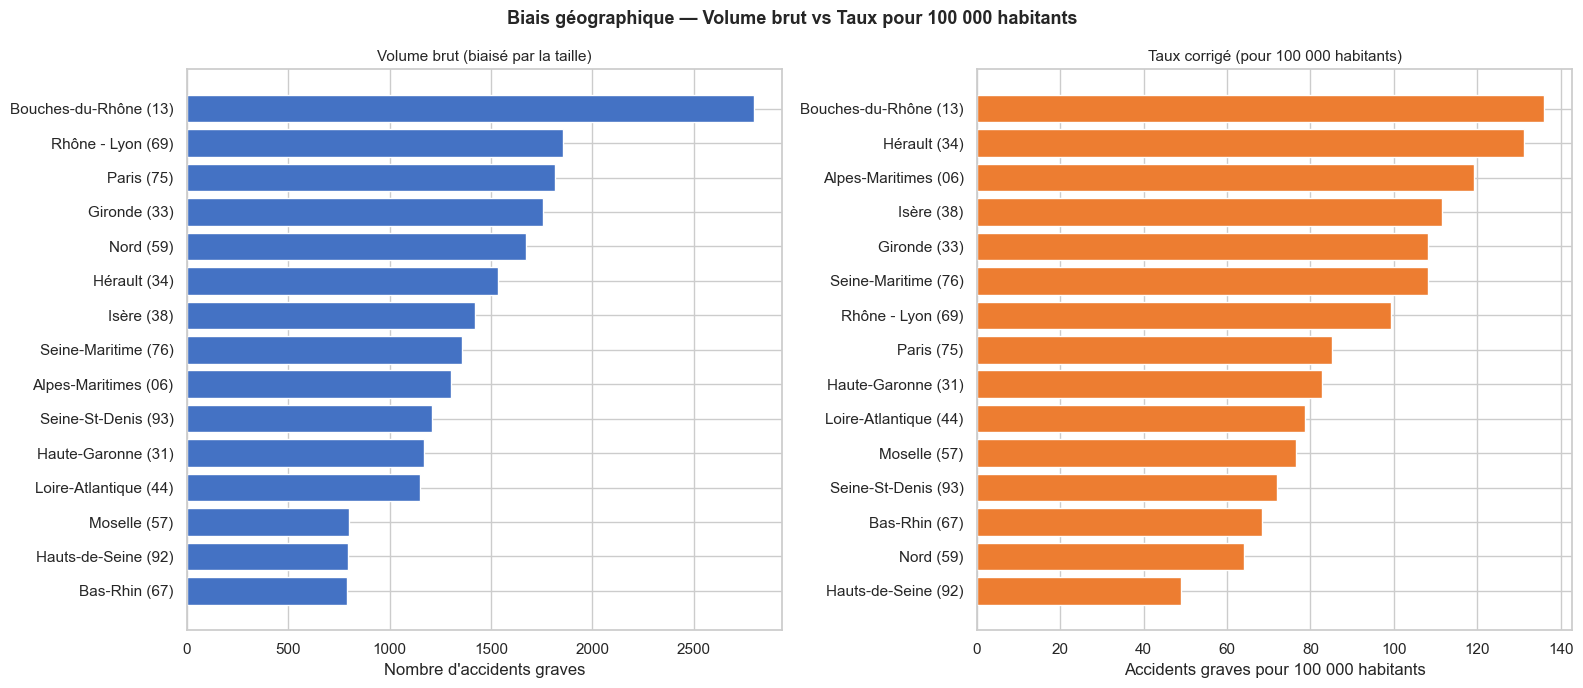

In [46]:
# Biais géographique — accidents graves pour 100 000 habitants

pop_dep = {
    '75': 2133111, '13': 2055749, '69': 1871606,
    '92': 1618489, '93': 1676178, '59': 2607810,
    '33': 1624034, '31': 1411445, '06': 1094185,
    '67': 1155906, '44': 1463000, '34': 1170000,
    '76': 1255000, '38': 1273000, '57': 1042000,
}
noms_dep = {
    '75': 'Paris (75)',          '13': 'Bouches-du-Rhône (13)', '69': 'Rhône - Lyon (69)',
    '92': 'Hauts-de-Seine (92)', '93': 'Seine-St-Denis (93)',   '59': 'Nord (59)',
    '33': 'Gironde (33)',        '31': 'Haute-Garonne (31)',     '06': 'Alpes-Maritimes (06)',
    '67': 'Bas-Rhin (67)',       '44': 'Loire-Atlantique (44)', '34': 'Hérault (34)',
    '76': 'Seine-Maritime (76)', '38': 'Isère (38)',             '57': 'Moselle (57)',
}

# dep est en float64 — on filtre les NaN avant de convertir en int
dep_acc = (
    df[df['grav'].isin([2, 3]) & df['dep'].notna()]
    .assign(dep=lambda x: x['dep'].astype(int).astype(str).str.zfill(2))
    .groupby('dep').size().rename('nb_accidents_graves').reset_index()
)
dep_acc = dep_acc[dep_acc['dep'].isin(pop_dep)].copy()
dep_acc['population']     = dep_acc['dep'].map(pop_dep)
dep_acc['taux_pour_100k'] = dep_acc['nb_accidents_graves'] / dep_acc['population'] * 100000
dep_acc['nom']            = dep_acc['dep'].map(noms_dep)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Biais géographique — Volume brut vs Taux pour 100 000 habitants', fontsize=13, fontweight='bold')

top_brut = dep_acc.sort_values('nb_accidents_graves')
axes[0].barh(top_brut['nom'], top_brut['nb_accidents_graves'], color='#4472C4')
axes[0].set_title("Volume brut (biaisé par la taille)", fontsize=11)
axes[0].set_xlabel("Nombre d'accidents graves")

top_taux = dep_acc.sort_values('taux_pour_100k')
axes[1].barh(top_taux['nom'], top_taux['taux_pour_100k'], color='#ED7D31')
axes[1].set_title("Taux corrigé (pour 100 000 habitants)", fontsize=11)
axes[1].set_xlabel("Accidents graves pour 100 000 habitants")

plt.tight_layout()
plt.savefig('./visualisations/viz_13_biais_geo.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observations :**
> - En volume brut, les grands départements dominent — c'est uniquement dû à leur taille
> - En taux corrigé (pour 100 000 habitants), le classement change significativement
> - **Conclusion :** utiliser `dep` en valeur brute sans normalisation introduit un biais de population dans le modèle

### 6.14 Carte GPS des accidents (France métropolitaine)

In [47]:
# je filtre sur la France métropolitaine
gps = df[
    df['lat'].between(41, 51) &
    df['long'].between(-5, 10)
][['lat','long','grav']].dropna()

# échantillon pour ne pas surcharger la carte
sample = gps.sample(min(5000, len(gps)), random_state=42)

carte = folium.Map(location=[46.6, 2.3], zoom_start=6)
HeatMap(sample[['lat','long']].values, radius=8).add_to(carte)
carte.save('./visualisations/viz_11_carte_accidents.html')
print('Carte sauvegardée → ./visualisations/viz_11_carte_accidents.html')
carte

Carte sauvegardée → ./visualisations/viz_11_carte_accidents.html


> **Observations :** les accidents sont concentrés sur les axes routiers majeurs et autour des grandes agglomérations.  
> Paris, Lyon, Marseille et les autoroutes ressortent clairement.

<a id='7-sauvegarde'></a>
## 7. Sauvegarde du dataset propre

---

In [48]:
# je sauvegarde le dataset nettoyé et fusionné
df.to_csv('../data/processed/dataset_clean.csv', index=False)
print(f'Dataset sauvegardé : {len(df):,} lignes | {df.shape[1]} colonnes')
print('Chemin : ../data/processed/dataset_clean.csv')

Dataset sauvegardé : 413,570 lignes | 44 colonnes
Chemin : ../data/processed/dataset_clean.csv


<a id='8-conclusion'></a>
## 8. Conclusion

---

## Bilan du notebook

### Ce que j'ai fait

**Chargement** — J'ai chargé les 12 fichiers BAAC (4 tables × 3 années) séparément pour pouvoir les inspecter avant de les assembler. C'est à cette étape que j'ai découvert que `caract` 2022 utilise `Accident_Id` au lieu de `Num_Acc` — un problème qui aurait cassé toutes les jointures silencieusement si je n'avais pas vérifié.

**Exploration** — J'ai comparé les colonnes entre les années, regardé les types, les valeurs manquantes réelles (NaN) et cachées (-1), les doublons, et la distribution de la variable cible `grav`. Les classes sont très déséquilibrées : beaucoup plus d'indemnes que de tués. C'est une information importante pour la modélisation.

**Nettoyage** — J'ai corrigé les problèmes identifiés : renommage `Accident_Id` → `Num_Acc`, remplacement des -1 par NaN, suppression des doublons stricts, conversion des coordonnées GPS (virgule → point), correction des types, et suppression des colonnes inutiles justifiée colonne par colonne à partir de la doc BAAC. J'ai aussi filtré sur la France métropolitaine pour exclure les DOM-TOM dont les conditions routières sont trop différentes.

**Merge** — J'ai fusionné les 4 tables en un seul dataset avec des left joins sur `Num_Acc`. Le dataset grossit à chaque merge avec `usagers` et `vehicules` car un accident peut impliquer plusieurs personnes et véhicules — c'est attendu.

**Visualisations** — 12 graphiques pour explorer les patterns : distribution de la gravité, évolution par année, accidents par heure, impact de la météo et de la luminosité, répartition par sexe et catégorie d'usager, type de route, heatmap heure × jour, gravité par véhicule, carte GPS et accidents graves par sexe.

---